In [9]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import torch.nn.functional as F

# NN Module

In [179]:
class SimpleDNN(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(input_shape, 2),
            nn.ReLU()
        )
    
    def forward(self, x):
        logits = self.linear_relu_stack(x)
        return F.softmax(logits, dim=1)

from tqdm import tqdm

def train_model(model, criterion, optimizer, train_loader, num_epochs=20, verbose=True):
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
        
        for inputs, labels in progress_bar:

            optimizer.zero_grad()  # Move this line before loss.backward()
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            if verbose:
                # Print inputs, outputs, labels, and loss
                print(f'Inputs: {inputs}')
                print(f'Outputs: {outputs}')
                print(f'Labels: {labels}')
                print(f'Loss: {loss.item()}')
            
            loss.backward()
            
            if verbose:
                # Print gradients
                for name, param in model.named_parameters():
                    if param.grad is not None:
                        print(f'Gradients for {name}: {param.grad}')
                    else:
                        print(f'No gradients for {name}')
            
            optimizer.step()
            
            if verbose:
                # Print weights after the optimizer step
                for name, param in model.named_parameters():
                    print(f'Weights for {name} after update: {param.data}')
            
            running_loss += loss.item() * inputs.size(0)
            
            # Update progress bar with current loss
            progress_bar.set_postfix(loss=loss.item())
        
        epoch_loss = running_loss / len(train_loader.dataset)
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}')

In [17]:
for name, param in model.named_parameters():
    print(f'{name} requires_grad: {param.requires_grad}')


linear_relu_stack.0.weight requires_grad: True
linear_relu_stack.0.bias requires_grad: True
linear_relu_stack.2.weight requires_grad: True
linear_relu_stack.2.bias requires_grad: True
linear_relu_stack.4.weight requires_grad: True
linear_relu_stack.4.bias requires_grad: True


In [251]:
df_data = pd.read_clipboard()

In [254]:
# Step 1: Prepare Data
# Assuming X is your features and y is your labels
# X, y should be numpy arrays
# For demonstration, we create random data
l_long_relabel = lambda x: 1 if x > 0 else 0
l_short_relabel = lambda x: 1 if x < 0 else 0

X = df_data[['trd_gap', 'a_price_sparsity', 'b_price_sparsity', 'int']] # 1000 samples, 30 features
X = df_data[['trd_gap']] # 1000 samples, 30 features
y = df_data['y_0.15'].apply(l_long_relabel).values

# Standardize features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Define the split point
split_point = int(len(X) * 0.7)

# Split the data
X_train, X_test = X[:split_point], X[split_point:]
y_train, y_test = y[:split_point], y[split_point:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)



In [57]:
train_loader.dataset.tensors[0].shape[1]

1

In [58]:
class PrecisionFocusedLoss(nn.Module):
    def __init__(self, profit_weight=0.2, loss_weight=0.35, fn_penalty=0.5):
        super(PrecisionFocusedLoss, self).__init__()
        self.profit_weight = profit_weight
        self.loss_weight = loss_weight
        self.fn_penalty = fn_penalty

    def forward(self, outputs, targets):
        # Convert outputs to predicted classes
        _, predicted_classes = torch.max(outputs, dim=1)

        # Identify true positives, false positives, and false negatives
        true_positives = (predicted_classes == 1) & (targets == 1)
        false_positives = (predicted_classes == 1) & (targets == 0)
        false_negatives = (predicted_classes == 0) & (targets == 1)

        # Precision calculation
        tp_sum = true_positives.sum().float()
        fp_sum = false_positives.sum().float()
        fn_sum = false_negatives.sum().float()

        # If no positive predictions, set precision to 0 to avoid division by zero
        precision = tp_sum / (tp_sum + fp_sum + 1e-10)

        # Profit and loss calculation based on precision
        profit = precision * tp_sum * self.profit_weight
        loss = (1 - precision) * fp_sum * self.loss_weight

        # Additional penalty for false negatives
        penalty = fn_sum * self.fn_penalty

        total_loss = -(profit - loss) + penalty

        # Ensure the loss requires gradients
        return total_loss.requires_grad_()

# TRAIN & TEST

In [213]:

# Create DataLoader
train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

model = SimpleDNN(train_loader.dataset.tensors[0].shape[1])
# Step 3: Define Loss and Optimizer
criterion = nn.CrossEntropyLoss()
criterion = PrecisionFocusedLoss()
optimizer = optim.Adam(model.parameters(), lr=1)


# Step 4: train model
train_model(model, criterion, optimizer, train_loader, num_epochs=10, verbose=False)

# Step 5: Evaluate the Model
model.eval()
correct = 0
total = 0
true_positives = 0
false_positives = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs)
        _, predicted = torch.max(outputs.data, 1)
        
        # Count total and correct predictions for accuracy
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Count true positives and false positives for class 1
        true_positives += ((predicted == 1) & (labels == 1)).sum().item()
        false_positives += ((predicted == 1) & (labels != 1)).sum().item()

# Calculate precision for class 1
if true_positives + false_positives > 0:
    precision_class_1 = true_positives / (true_positives + false_positives)
else:
    precision_class_1 = 0

print(f'Accuracy of the model on the test set: {100 * correct / total:.2f}%')
print(f'Precision for class 1: {precision_class_1:.2f}')


Epoch 1/10, Loss: 1418.3795


Epoch 2/10, Loss: 1418.4217


Epoch 3/10, Loss: 1418.3725


Epoch 4/10, Loss: 1418.3801


Epoch 5/10, Loss: 1418.3887


Epoch 6/10, Loss: 1418.3960


Epoch 7/10, Loss: 1418.3832


Epoch 8/10, Loss: 1418.3977


Epoch 9/10, Loss: 1418.4082


Epoch 10/10, Loss: 1418.3967
Accuracy of the model on the test set: 62.75%
Precision for class 1: 0.24


# Model visualize

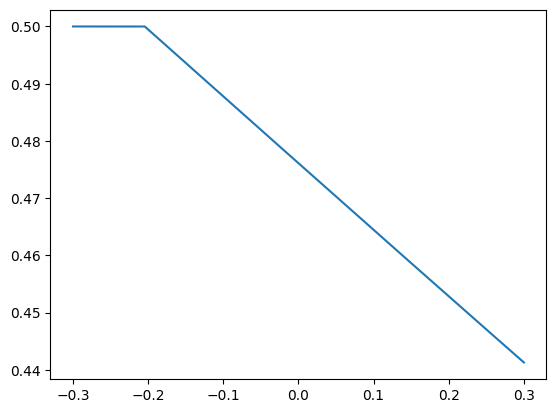

In [214]:
y_values = []
for gap in torch.linspace(-0.3, 0.3, 1000):
    y_values.append(model(torch.tensor([[gap]]))[0][1].item())
    
x_values = np.linspace(-0.3, 0.3, 1000)
import matplotlib.pyplot as plt
plt.plot(x_values, y_values)

In [178]:
model(torch.tensor([[0.20]]))[0]

tensor([1.], grad_fn=<SelectBackward0>)

## relabel

In [276]:
df_data = pd.read_clipboard()

In [277]:
df_data['y'] = df_data['y_0.15'].apply(l_long_relabel)

In [278]:
df_data

,trd_gap,a_price_sparsity,b_price_sparsity,int,y_0.15,y
5957,0.00,0.28,0.35,0.892932,1.0,1
5958,0.00,0.18,0.35,1.322045,0.0,0
5959,0.00,0.41,0.29,0.892932,0.0,0
5960,0.00,0.41,0.29,1.662230,0.0,0
5961,0.00,0.41,0.29,2.428508,0.0,0
...,...,...,...,...,...,...
331626,0.04,0.20,0.51,5.549586,1.0,1
331627,0.04,0.20,0.51,6.292355,1.0,1
331628,0.04,0.20,0.51,7.033911,1.0,1
331629,0.00,0.23,0.48,4.441639,1.0,1


In [280]:
df_data

,trd_gap,a_price_sparsity,b_price_sparsity,int,y_0.15,y
5957,0.00,0.28,0.35,0.892932,1.0,1
5958,0.00,0.18,0.35,1.322045,0.0,0
5959,0.00,0.41,0.29,0.892932,0.0,0
5960,0.00,0.41,0.29,1.662230,0.0,0
5961,0.00,0.41,0.29,2.428508,0.0,0
...,...,...,...,...,...,...
331626,0.04,0.20,0.51,5.549586,1.0,1
331627,0.04,0.20,0.51,6.292355,1.0,1
331628,0.04,0.20,0.51,7.033911,1.0,1
331629,0.00,0.23,0.48,4.441639,1.0,1


In [294]:
df_data.describe()

,trd_gap,a_price_sparsity,b_price_sparsity,int,y_0.15,y
count,325273.000000,325273.000000,325273.000000,325273.000000,325273.000000,325273.000000
mean,-0.000029,0.125693,0.128265,1.636295,0.012297,0.325536
std,0.029188,0.071450,0.077986,1.510271,0.799140,0.468575
min,-0.300000,0.000000,0.000000,0.102896,-1.000000,0.000000
25%,0.000000,0.080000,0.080000,0.858069,-1.000000,0.000000
50%,0.000000,0.110000,0.110000,1.026634,0.000000,0.000000
75%,0.000000,0.150000,0.160000,1.804233,1.000000,1.000000
max,0.300000,1.000000,1.000000,31.372067,1.000000,1.000000


(0.0, 500.0)

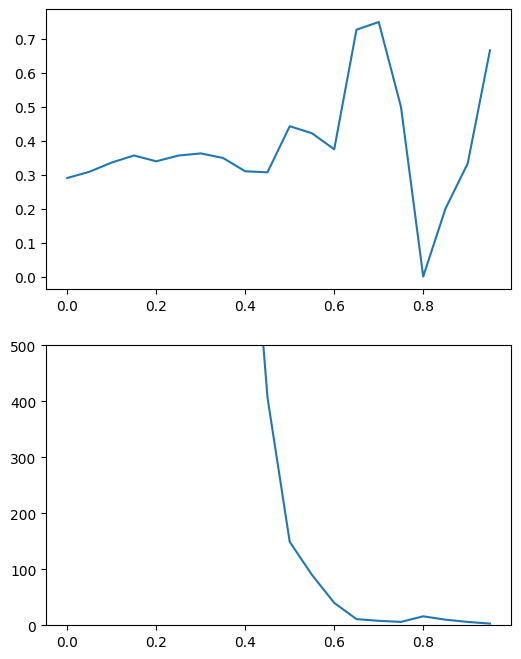

In [295]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 8))

y_values = []
size_values = []
for gap in np.arange(0.0, 1.0, 0.05):
    aux_df = df_data[(df_data['a_price_sparsity'] > gap) & (df_data['a_price_sparsity'] < gap+0.05)]['y'].copy()
    y_values.append(aux_df.mean())
    size_values.append(len(aux_df))
x_values = np.arange(0.0, 1.0, 0.05)
import matplotlib.pyplot as plt
ax1.plot(x_values, y_values)
ax2.plot(x_values, size_values)
ax2.set_ylim(ymin=0, ymax=500)

In [223]:
df_data[df_data['trd_gap'] > 0.05][['trd_gap', 'y']].corr('spearman').values[0,1]

0.061250166741971174

In [268]:
df_data['y'].mean()

0.3255357807134315

In [172]:
import seaborn as sns

sns.regplot(df_data[['trd_gap', 'y']], x='trd_gap', y='y')

KeyError: 'y'

In [269]:
from sklearn.metrics import roc_auc_score

2*roc_auc_score(df_data[
'y'
], df_data[
'trd_gap'
])-1


0.08849505756782827

In [270]:
df_data

,trd_gap,a_price_sparsity,b_price_sparsity,int,y_0.15,y
5957,0.00,0.28,0.35,0.892932,1.0,1
5958,0.00,0.18,0.35,1.322045,0.0,0
5959,0.00,0.41,0.29,0.892932,0.0,0
5960,0.00,0.41,0.29,1.662230,0.0,0
5961,0.00,0.41,0.29,2.428508,0.0,0
...,...,...,...,...,...,...
331626,0.04,0.20,0.51,5.549586,1.0,1
331627,0.04,0.20,0.51,6.292355,1.0,1
331628,0.04,0.20,0.51,7.033911,1.0,1
331629,0.00,0.23,0.48,4.441639,1.0,1


   segment  count  response_rate      lift
0        1    100           0.51  1.022044
1        2    100           0.45  0.901804
2        3    100           0.42  0.841683
3        4    100           0.50  1.002004
4        5    100           0.55  1.102204
5        6    100           0.47  0.941884
6        7    100           0.55  1.102204
7        8    100           0.46  0.921844
8        9    100           0.48  0.961924
9       10    100           0.60  1.202405


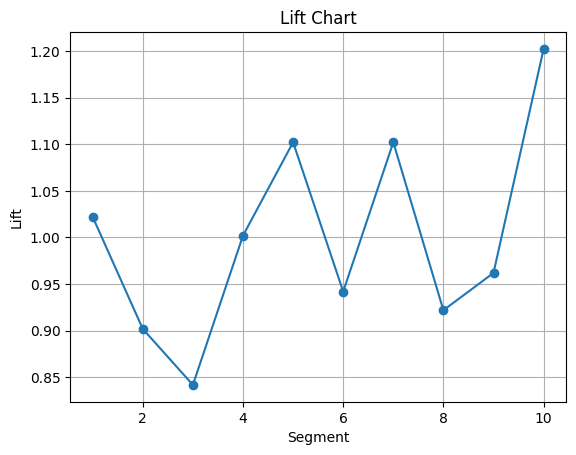

In [271]:
import pandas as pd
import numpy as np

# Sample data
# Assuming df_data is a pandas DataFrame with columns 'predicted_proba' (predicted probabilities) and 'actual' (actual labels)
np.random.seed(42)
df_data = pd.DataFrame({
    'predicted_proba': np.random.rand(1000),
    'actual': np.random.choice([0, 1], 1000)
})

# Step 1: Sort predictions
df_data = df_data.sort_values(by='predicted_proba', ascending=False).reset_index(drop=True)

# Step 2: Segment the data
num_segments = 10  # Deciles
segment_size = len(df_data) // num_segments

df_data['segment'] = np.repeat(np.arange(1, num_segments + 1), segment_size)[:len(df_data)]

# Handle the remaining data points (if any) due to integer division
if len(df_data) % num_segments != 0:
    df_data.loc[len(df_data) - (len(df_data) % num_segments):, 'segment'] = num_segments

# Step 3: Calculate the baseline
baseline = df_data['actual'].mean()

# Step 4: Calculate lift for each segment
lift_df = df_data.groupby('segment').agg(
    count=('actual', 'size'),
    response_rate=('actual', 'mean')
).reset_index()

lift_df['lift'] = lift_df['response_rate'] / baseline

# Display the lift metrics
print(lift_df)

# Plot the lift chart
import matplotlib.pyplot as plt

plt.plot(lift_df['segment'], lift_df['lift'], marker='o')
plt.xlabel('Segment')
plt.ylabel('Lift')
plt.title('Lift Chart')
plt.grid(True)
plt.show()
